Total Portfolio: $249,794,491.41
Total Invoiced: $25,768,971.88
Total Remaining: $224,025,519.53
    company_name  Total_PO_Amount  Total_Invoiced  Remaining_Balance  \
151        Lazzy         52751.26       652340.50         -599589.24   
266       Tagpad         94379.77       500310.44         -405930.67   
54       Dablist        119260.70       611954.85         -492694.15   
247      Skilith        196580.53       761462.61         -564882.08   
139         Kare        192111.35       730212.39         -538101.04   
..           ...              ...             ...                ...   
124   Jabbertype        773709.90            0.00          773709.90   
125        Jaloo        229053.59            0.00          229053.59   
126        Jamia       1052807.35            0.00         1052807.35   
127        Janyx        147804.94            0.00          147804.94   
118      Innojam        412153.39            0.00          412153.39   

    Billing_Status  Utilization_Rate  

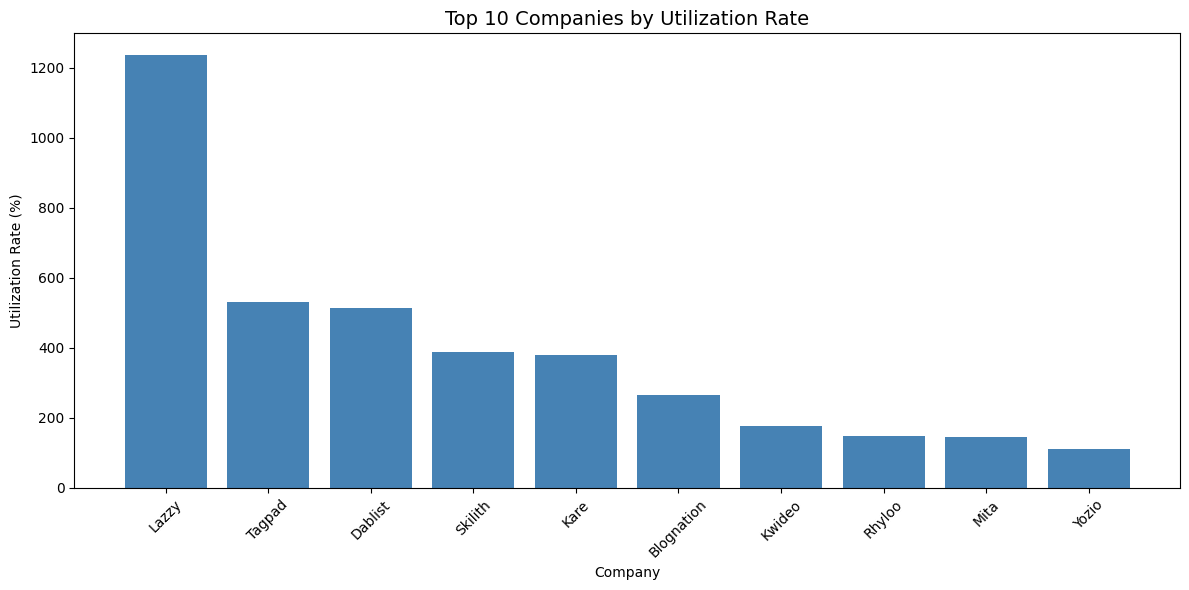

In [10]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Load both CSVs
po_df = pd.read_csv('PurchaseOrderData.csv')
inv_df = pd.read_csv('InvoiceData.csv')

# Create database
conn = sqlite3.connect(':memory:')

# Load both into the database as separate tables
po_df.to_sql('purchase_orders', conn, index=False, if_exists='replace')
inv_df.to_sql('invoices', conn, index=False, if_exists='replace')

df = pd.read_sql_query("""
SELECT
po.company_name,
po.Total_PO_Amount,
COALESCE(inv.Total_Invoiced, 0) AS Total_Invoiced,
po.Total_PO_Amount - COALESCE(inv.Total_Invoiced, 0) AS Remaining_Balance,
CASE
    WHEN inv.Total_Invoiced IS NULL THEN 'Not Billed'
    WHEN po.Total_PO_Amount - COALESCE(inv.Total_Invoiced, 0) < 0 THEN 'Over Limit'
    ELSE 'Billed'
END AS Billing_Status
FROM
(
SELECT
company_name,
SUM(purchase_order_amount) AS Total_PO_Amount
FROM purchase_orders
GROUP BY company_name
) po
LEFT JOIN
(
SELECT
p.company_name,
SUM(i.invoice_amount) AS Total_Invoiced
FROM invoices i
JOIN purchase_orders p
ON i.purchase_order_id = p.purchase_order_id
GROUP BY company_name
) inv
ON po.company_name = inv.company_name
""", conn)

df = df.round(2)

df.isnull().sum()
df = df.fillna(0)

df['Utilization_Rate'] = ((df['Total_Invoiced']) / (df['Total_PO_Amount']) * 100).round(2)
df['Revenue_Share'] = ((df['Total_Invoiced']/ df['Total_Invoiced'].sum())*100).round(2)
df['Risk_Level'] = df['Utilization_Rate'].apply(lambda x: 'High Risk' if x > 75 else 'Mid Risk' if x > 40 else 'Low Risk')
df['Rank'] = df['Utilization_Rate'].rank(ascending=False).astype(int)
df = df.sort_values('Utilization_Rate', ascending=False)
print(f"Total Portfolio: ${df['Total_PO_Amount'].sum():,.2f}")
print(f"Total Invoiced: ${df['Total_Invoiced'].sum():,.2f}")
print(f"Total Remaining: ${df['Remaining_Balance'].sum():,.2f}")
print(df)

top10 = df.nlargest(10, 'Utilization_Rate')

top10 = df.nlargest(10, 'Utilization_Rate')

plt.figure(figsize=(12, 6))
plt.bar(top10['company_name'], top10['Utilization_Rate'], color='steelblue')
plt.title('Top 10 Companies by Utilization Rate', fontsize=14)
plt.xlabel('Company')
plt.ylabel('Utilization Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df.to_excel('utilization_tracker.xlsx', index=False)